The aim of this notebook is to be able to develop an augmented reality (AR) video, using two source videos. The first video shows two books: Computer Vision (A Modern Approach) and Multiple View Geometry (in computer vision). The second video is the trailer of the animated movie: Kung Fu Panda.

**TASK**

The aim of this task is to be able to overlay every frame of the Kung Fu Panda movie over the Computer Vision book in the second movie.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# SIFT function performing the SIFT Descriptor
def SIFT(img):
  # Instantiate SIFT object
  sift = cv2.SIFT_create()
  keypoints, descriptors = sift.detectAndCompute(img, None)
  image_detected_blobs = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  return image_detected_blobs, keypoints, descriptors


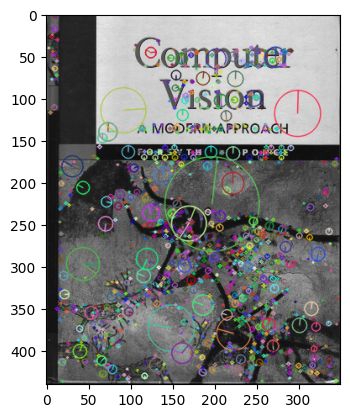

In [ ]:
# Reading input image (Book cover)
image = cv2.imread('cv_cover.jpg')
img_grayscale = cv2.imread('cv_cover.jpg', cv2.IMREAD_GRAYSCALE)
# SIFT Outcome plotted
sift_outcome = SIFT(img_grayscale)
image_detected_blobs_A = sift_outcome[0]
keypoints_A = sift_outcome[1]
descriptors_A = sift_outcome[2]
plt.imshow(image_detected_blobs_A)

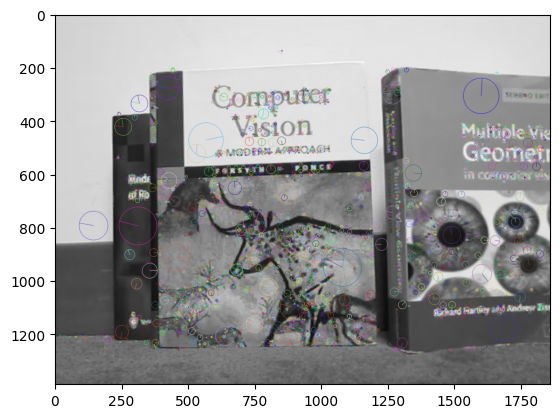

In [ ]:
# Reading input image (Book cover -- first frame in the first movie)
image_movie = cv2.imread('cv_cover_movie.jpg')
img_grayscale_movie = cv2.imread('cv_cover_movie.jpg', cv2.IMREAD_GRAYSCALE)
# SIFT Outcome plotted
sift_outcome_movie = SIFT(img_grayscale_movie)
image_detected_blobs_B = sift_outcome_movie[0]
keypoints_B = sift_outcome_movie[1]
descriptors_B = sift_outcome_movie[2]
plt.imshow(image_detected_blobs_B)

In [ ]:
# Brute force function. Matcher used to obtain the correspondances between images
def brute_force(image_A, image_keypoints_A ,image_descriptors_A, image_B, image_keypoints_B ,image_descriptors_B):
  brute_force_matcher = cv2.BFMatcher()
  # K Nearest Neighbors, Neighbors = 2
  neighbors = 2
  matches = brute_force_matcher.knnMatch(image_descriptors_A, image_descriptors_B, neighbors)
  # matches = sorted(matches, key=lambda x:x[0].distance)
  # Select only good matches according to ratio. According to Lowe's paper, a match with ratio of 0.65 is a good match
  ratio = 0.65
  good_matches = []
  for m, n in matches:
    if m.distance < ratio*n.distance:
      good_matches.append([m])
  number_of_matches = 50
  good_matches = good_matches[:number_of_matches]
  image_with_matches = cv2.drawMatchesKnn(image_A, image_keypoints_A, image_B, image_keypoints_B, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
  return image_with_matches, good_matches

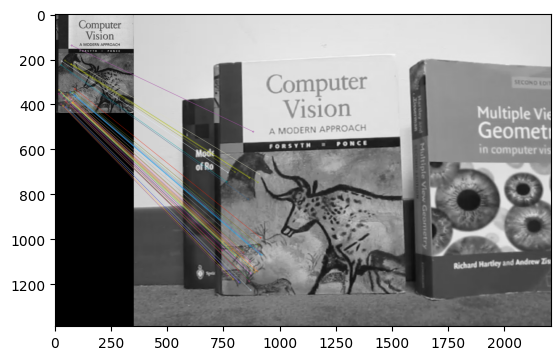

In [ ]:
# Brute force matcher outcome
brute_force_outcome = brute_force(img_grayscale, keypoints_A, descriptors_A, img_grayscale_movie, keypoints_B, descriptors_B)
plt.imshow(brute_force_outcome[0])


In [57]:
# Computing the homography parameters
def compute_homography(matches, keypoints_A, keypoints_B):
  # Compute correspondences first. Find pairs of x and y values.
  # Pairs must be correctly aligned.
  # Correspondences between 'cv_cover.jpg' and 'cv_cover_movie.jpg'
  points_A = np.zeros((len(matches), 2), dtype=np.float32)
  points_B = np.zeros((len(matches), 2), dtype=np.float32)
  for i, match in enumerate(matches):
    m = match[0]
    points_A[i, :] = keypoints_A[m.queryIdx].pt
    points_B[i, :] = keypoints_B[m.trainIdx].pt
  # Finding the homography matrix through solving a system of equations. Each correspondences (x,y) provides 2 equations
  # 8 unknowns in H are stacked on top of one another, 9th term (3,3) is set to 1
  # To find the 8 unknowns, we need at least 4 correspondences.
  # Solving Ah = 0. h contains all 8 unknown homography parameters stacked on top of each other.
  # A is a 2n * 9 matrix, n being the number of correspondences.

  A = np.zeros((2*len(points_A), 9), dtype=np.float32)
  for i in range(len(points_A)):
    A[2*i, :] = [-points_A[i, 0], -points_A[i, 1], -1, 0, 0, 0, points_B[i, 0]*points_A[i, 0], points_B[i, 0]*points_A[i, 1], points_B[i, 0]]
    A[2*i+1, :] = [0, 0, 0, -points_A[i, 0], -points_A[i, 1], -1, points_B[i, 1]*points_A[i, 0], points_B[i, 1]*points_A[i, 1], points_B[i, 1]]
    # Singular Value Decomposition for the matrix A
  U, S, V = np.linalg.svd(A)
  # Store the singular vector of the smallest singular value
  smallest_signular_vector = V[-1, :]
  # Reshape to get H
  H = smallest_signular_vector.reshape(3, 3)
  H = H / H[-1, -1]

  return H, points_A, points_B

Calculated H:
 [[ 2.1876452e+00  4.5102607e-02  3.4392932e+02]
 [-4.2856765e-01  2.4101527e+00  2.1039717e+02]
 [-3.5254034e-04  2.6806812e-05  1.0000000e+00]]
H from Builtin Function:
 [[ 2.32248920e+00  6.92150689e-02  3.40015287e+02]
 [-2.71213245e-01  2.50745758e+00  1.93519549e+02]
 [-1.97207679e-04  7.18883858e-05  1.00000000e+00]]


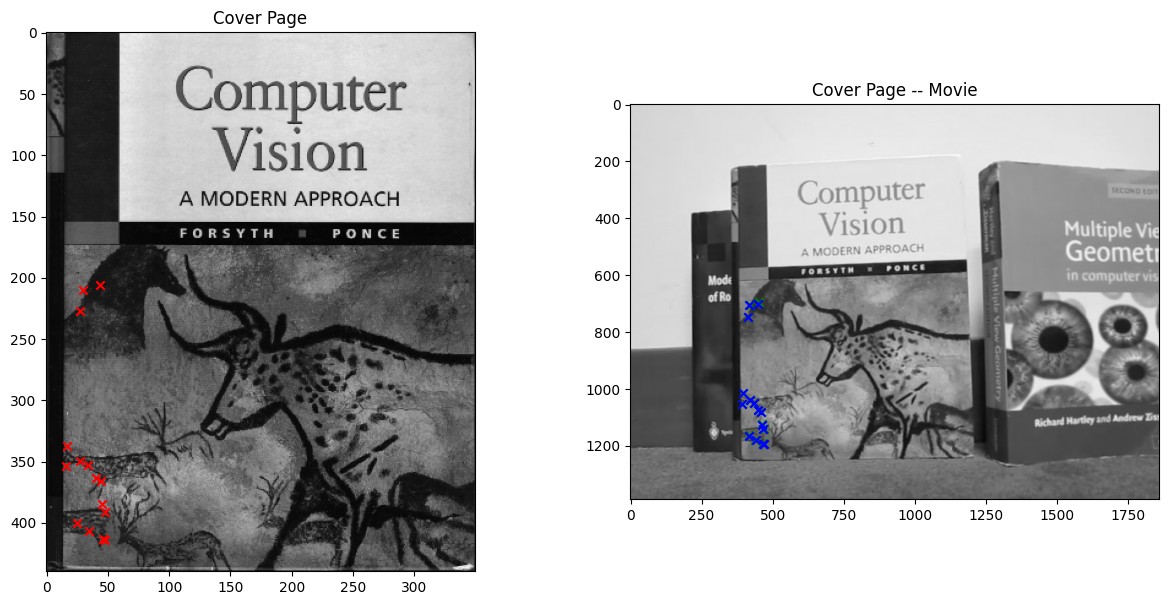

In [67]:
H, points_A, points_B =compute_homography(brute_force_outcome[1], keypoints_A, keypoints_B)

H_built_in, _ = cv2.findHomography(points_A, points_B, 0)

print('Calculated H:\n',H)
print('H from Builtin Function:\n', H_built_in)

# Testing the validity of the computed H matrix
# Testing on the first 10 correspondences between A and B
A_image_points = []
B_image_points = []
estimated_image_points = []
for i in range(15):
  x_A = points_A[i, 0]
  y_A = points_A[i, 1]
  A_image_points.append([x_A, y_A])
  x_B = points_B[i, 0]
  y_B = points_B[i, 1]
  B_image_points.append([x_B, y_B])
  # Transform to homogeneous coordinates (A --> input), (B --> ground truth)
  point_A_homogeneous = np.array([points_A[i, 0], points_A[i, 1], 1])
  # Homography output (estimated)
  point_B_homogeneous_esitimated = np.dot(H, point_A_homogeneous)
  # homogeneous --> heterogeneous again
  w_estimated = point_B_homogeneous_esitimated[2]
  y_estimated = point_B_homogeneous_esitimated[1] / w_estimated
  x_estimated = point_B_homogeneous_esitimated[0] / w_estimated
  estimated_image_points.append([x_estimated, y_estimated])

A_points = np.array(A_image_points)
B_points = np.array(B_image_points)
estimated_points = np.array(estimated_image_points)

# Making images appear side by side
figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.imshow(img_grayscale, cmap='gray')
ax1.scatter(A_points[:,0], A_points[:,1], c='r', marker='x')
ax1.set_title('Cover Page')

ax2.imshow(img_grayscale_movie, cmap='gray')
ax2.scatter(estimated_points[:,0], estimated_points[:,1], c='g', marker='x')
ax2.scatter(B_points[:,0], B_points[:,1], c='b', marker='x')
ax2.set_title('Cover Page -- Movie')

plt.show()


